In [1]:
from pathlib import Path
import re

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, NullLocator

DT = 0.01
RATE_MAX = 40.0
SEED = 42
AREA_KEY = "area-A0"

noise_runs_dir = Path("..") / "runs" / "noise_runs"
noise_run_dirs = sorted(
    [p for p in noise_runs_dir.iterdir() if p.is_dir()],
    key=lambda p: float(re.search(r"_n([\d.]+)_", p.name).group(1)),
)


def parse_noise(run_name: str) -> float:
    return float(re.search(r"_n([\d.]+)_", run_name).group(1))


def activity_to_rates(activity: np.ndarray, *, clip_rates: bool) -> np.ndarray:
    rates = RATE_MAX * (activity + 1.0) / 2.0
    if clip_rates:
        return np.clip(rates, 0.0, RATE_MAX)
    return np.clip(rates, 0.0, None)


def activity_to_lam(activity: np.ndarray, *, clip_rates: bool) -> np.ndarray:
    return activity_to_rates(activity, clip_rates=clip_rates) * DT


def activity_to_counts(activity: np.ndarray, *, clip_rates: bool, rng: np.random.Generator) -> np.ndarray:
    return rng.poisson(activity_to_lam(activity, clip_rates=clip_rates)).astype(np.float32)

In [2]:
rows = []
rng = np.random.default_rng(SEED)

for run_dir in noise_run_dirs:
    noise = parse_noise(run_dir.name)
    with h5py.File(run_dir / "data.h5", "r") as h:
        activity = h["0"][AREA_KEY][:]

    flat = activity.reshape(-1)
    rates_unclip = activity_to_rates(flat, clip_rates=False)
    rates_clip = activity_to_rates(flat, clip_rates=True)
    lam_unclip = rates_unclip * DT
    lam_clip = rates_clip * DT
    counts_unclip = rng.poisson(lam_unclip).astype(np.float32)
    counts_clip = rng.poisson(lam_clip).astype(np.float32)

    rows.append(
        {
            "noise": noise,
            "run_name": run_dir.name,
            "n_neurons": activity.shape[-1],
            "activity_min": float(flat.min()),
            "activity_max": float(flat.max()),
            "frac_below_-1": float((flat < -1).mean()),
            "frac_above_1": float((flat > 1).mean()),
            "frac_outside_-1_1": float((np.abs(flat) > 1).mean()),
            "frac_rate_capped": float((rates_unclip > RATE_MAX).mean()),
            "mean_lam_unclip": float(lam_unclip.mean()),
            "mean_lam_clip": float(lam_clip.mean()),
            "mean_lam_ratio": float(lam_clip.mean() / lam_unclip.mean()),
            "max_lam_unclip": float(lam_unclip.max()),
            "max_lam_clip": float(lam_clip.max()),
            "mean_count_unclip": float(counts_unclip.mean()),
            "mean_count_clip": float(counts_clip.mean()),
            "mean_count_ratio": float(counts_clip.mean() / counts_unclip.mean()),
            "std_count_unclip": float(counts_unclip.std()),
            "std_count_clip": float(counts_clip.std()),
        }
    )

summary_df = pd.DataFrame(rows).sort_values("noise")
summary_df

,noise,run_name,n_neurons,activity_min,activity_max,frac_below_-1,frac_above_1,frac_outside_-1_1,frac_rate_capped,mean_lam_unclip,mean_lam_clip,mean_lam_ratio,max_lam_unclip,max_lam_clip,mean_count_unclip,mean_count_clip,mean_count_ratio,std_count_unclip,std_count_clip
0,0.001,memory_network_h512_n0.001_id2606221443,512,-1.004861,1.005260,0.039323,0.039487,0.078810,0.039482,0.194364,0.194358,0.999972,0.401052,0.4,0.194338,0.194425,1.000447,0.469865,0.469863
1,0.005,memory_network_h512_n0.005_id2606221443,512,-1.023879,1.024047,0.023367,0.029985,0.053352,0.029985,0.204402,0.204382,0.999899,0.404809,0.4,0.204367,0.204365,0.999994,0.476569,0.476489
2,0.010,memory_network_h512_n0.01_id2606221443,512,-1.050457,1.054255,0.052177,0.063025,0.115202,0.063024,0.211606,0.211516,0.999577,0.410851,0.4,0.211586,0.211436,0.999293,0.485977,0.485814
3,0.050,memory_network_h512_n0.05_id2606221443,512,-1.273381,1.260133,0.100822,0.099323,0.200145,0.099323,0.199840,0.199097,0.996278,0.452027,0.4,0.199827,0.199072,0.996219,0.476117,0.474983
4,0.100,memory_network_h512_n0.1_id2606221443,512,-1.504691,1.532149,0.114301,0.112918,0.227219,0.112918,0.201224,0.199556,0.991708,0.506430,0.4,0.201187,0.199525,0.991735,0.476956,0.474428
5,0.500,memory_network_h512_n0.5_id2606221443,512,-3.795393,3.849283,0.208720,0.221963,0.430683,0.221963,0.221454,0.204311,0.922589,0.969857,0.4,0.221414,0.204329,0.922833,0.506270,0.480304
6,1.000,memory_network_h512_n1_id2606221443,512,-6.434523,6.377512,0.245567,0.245061,0.490628,0.245061,0.236599,0.199869,0.844759,1.475502,0.4,0.236616,0.199751,0.844201,0.533865,0.475262
7,2.000,memory_network_h512_n2_id2606221443,512,-12.086372,11.676082,0.327335,0.327115,0.654451,0.327115,0.294591,0.199961,0.678775,2.535216,0.4,0.294505,0.200079,0.679375,0.631327,0.480389
8,5.000,memory_network_h512_n5_id2606221443,512,-28.768305,27.781538,0.422161,0.422338,0.844499,0.422338,0.514477,0.200031,0.388804,5.756307,0.4,0.514528,0.200061,0.388823,0.976233,0.485672


In [3]:
display_cols = [
    "noise",
    "activity_min",
    "activity_max",
    "frac_outside_-1_1",
    "frac_rate_capped",
    "mean_lam_unclip",
    "mean_lam_clip",
    "mean_lam_ratio",
    "max_lam_unclip",
    "max_lam_clip",
    "mean_count_unclip",
    "mean_count_clip",
    "mean_count_ratio",
]
summary_df[display_cols].round(4)

,noise,activity_min,activity_max,frac_outside_-1_1,frac_rate_capped,mean_lam_unclip,mean_lam_clip,mean_lam_ratio,max_lam_unclip,max_lam_clip,mean_count_unclip,mean_count_clip,mean_count_ratio
0,0.001,-1.0049,1.0053,0.0788,0.0395,0.1944,0.1944,1.0000,0.4011,0.4,0.1943,0.1944,1.0004
1,0.005,-1.0239,1.0240,0.0534,0.0300,0.2044,0.2044,0.9999,0.4048,0.4,0.2044,0.2044,1.0000
2,0.010,-1.0505,1.0543,0.1152,0.0630,0.2116,0.2115,0.9996,0.4109,0.4,0.2116,0.2114,0.9993
3,0.050,-1.2734,1.2601,0.2001,0.0993,0.1998,0.1991,0.9963,0.4520,0.4,0.1998,0.1991,0.9962
4,0.100,-1.5047,1.5321,0.2272,0.1129,0.2012,0.1996,0.9917,0.5064,0.4,0.2012,0.1995,0.9917
5,0.500,-3.7954,3.8493,0.4307,0.2220,0.2215,0.2043,0.9226,0.9699,0.4,0.2214,0.2043,0.9228
6,1.000,-6.4345,6.3775,0.4906,0.2451,0.2366,0.1999,0.8448,1.4755,0.4,0.2366,0.1998,0.8442
7,2.000,-12.0864,11.6761,0.6545,0.3271,0.2946,0.2000,0.6788,2.5352,0.4,0.2945,0.2001,0.6794
8,5.000,-28.7683,27.7815,0.8445,0.4223,0.5145,0.2000,0.3888,5.7563,0.4,0.5145,0.2001,0.3888


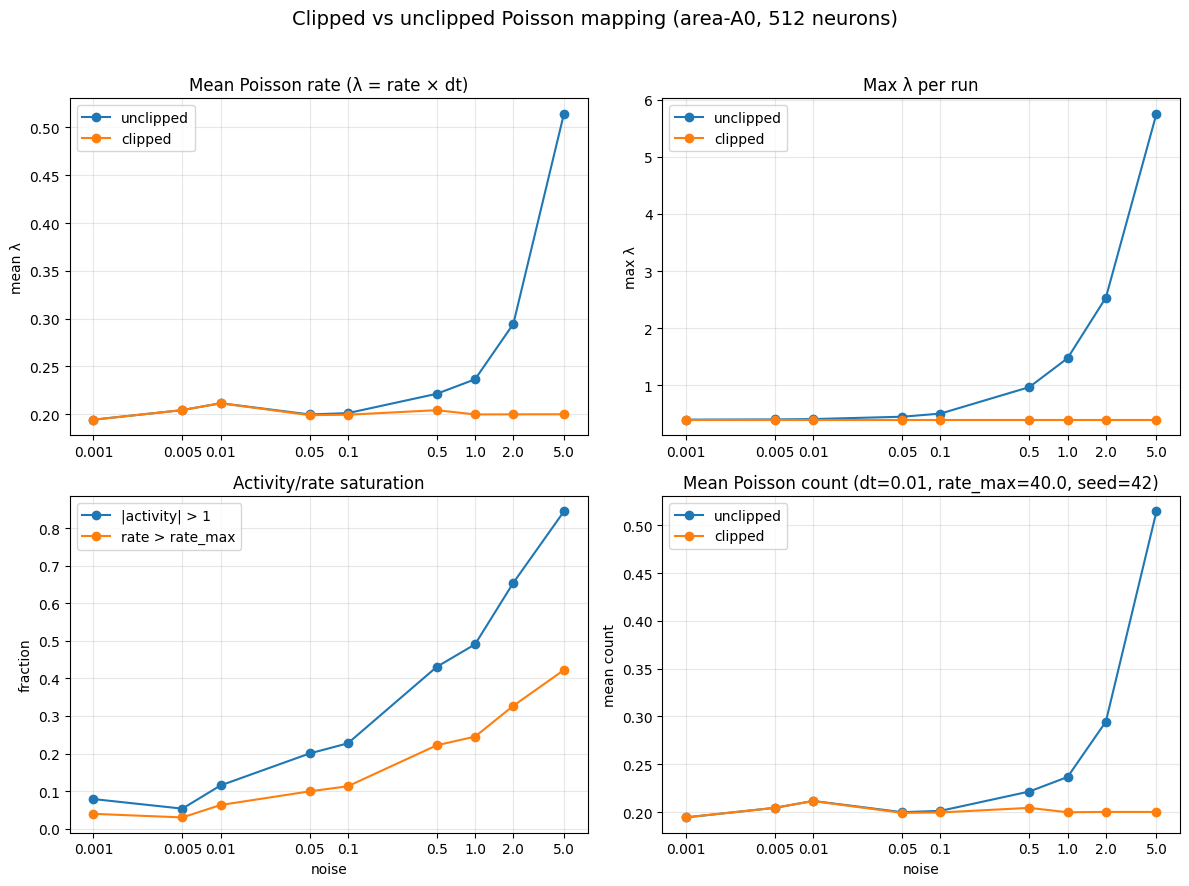

In [4]:
noise_levels = summary_df["noise"].to_numpy()

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

ax = axes[0, 0]
ax.plot(noise_levels, summary_df["mean_lam_unclip"], "o-", label="unclipped")
ax.plot(noise_levels, summary_df["mean_lam_clip"], "o-", label="clipped")
ax.set_xscale("log")
ax.set_ylabel("mean λ")
ax.set_title("Mean Poisson rate (λ = rate × dt)")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[0, 1]
ax.plot(noise_levels, summary_df["max_lam_unclip"], "o-", label="unclipped")
ax.plot(noise_levels, summary_df["max_lam_clip"], "o-", label="clipped")
ax.set_xscale("log")
ax.set_ylabel("max λ")
ax.set_title("Max λ per run")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1, 0]
ax.plot(noise_levels, summary_df["frac_outside_-1_1"], "o-", color="C0", label="|activity| > 1")
ax.plot(noise_levels, summary_df["frac_rate_capped"], "o-", color="C1", label="rate > rate_max")
ax.set_xscale("log")
ax.set_ylabel("fraction")
ax.set_title("Activity/rate saturation")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1, 1]
ax.plot(noise_levels, summary_df["mean_count_unclip"], "o-", label="unclipped")
ax.plot(noise_levels, summary_df["mean_count_clip"], "o-", label="clipped")
ax.set_xscale("log")
ax.set_ylabel("mean count")
ax.set_title(f"Mean Poisson count (dt={DT}, rate_max={RATE_MAX}, seed={SEED})")
ax.legend()
ax.grid(True, alpha=0.3)

for ax in axes.flat:
    ax.xaxis.set_major_locator(FixedLocator(noise_levels))
    ax.xaxis.set_minor_locator(NullLocator())
    ax.set_xticklabels([str(n) for n in noise_levels])
    if ax in (axes[1, 0], axes[1, 1]):
        ax.set_xlabel("noise")

fig.suptitle(f"Clipped vs unclipped Poisson mapping ({AREA_KEY}, 512 neurons)", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

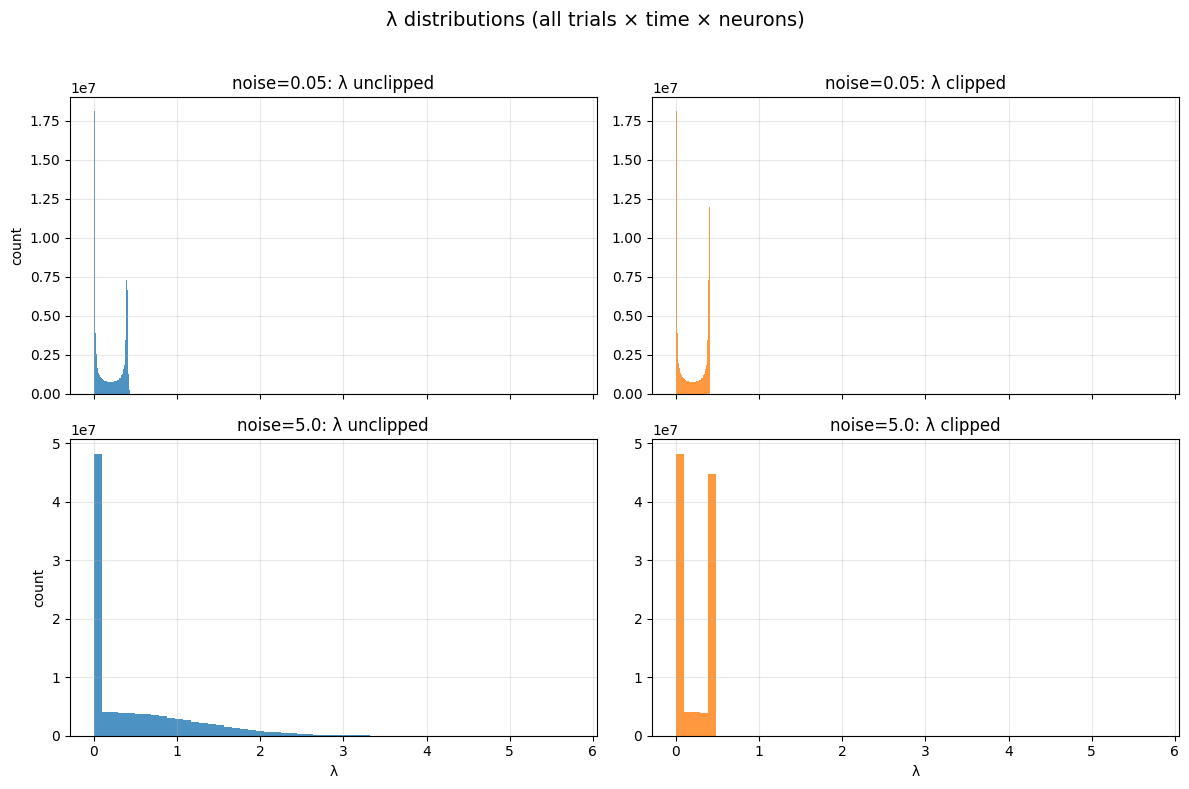

In [5]:
# Example λ distributions at low vs high noise
example_noises = [0.05, 5.0]
example_runs = {parse_noise(p.name): p for p in noise_run_dirs}

fig, axes = plt.subplots(len(example_noises), 2, figsize=(12, 8), sharex=True)

for row, noise in enumerate(example_noises):
    with h5py.File(example_runs[noise] / "data.h5", "r") as h:
        activity = h["0"][AREA_KEY][:].reshape(-1)

    lam_unclip = activity_to_lam(activity, clip_rates=False)
    lam_clip = activity_to_lam(activity, clip_rates=True)

    bins = np.linspace(0, max(lam_unclip.max(), lam_clip.max()), 60)

    axes[row, 0].hist(lam_unclip, bins=bins, alpha=0.8, color="C0")
    axes[row, 0].set_ylabel("count")
    axes[row, 0].set_title(f"noise={noise}: λ unclipped")
    axes[row, 0].grid(True, alpha=0.3)

    axes[row, 1].hist(lam_clip, bins=bins, alpha=0.8, color="C1")
    axes[row, 1].set_title(f"noise={noise}: λ clipped")
    axes[row, 1].grid(True, alpha=0.3)

axes[-1, 0].set_xlabel("λ")
axes[-1, 1].set_xlabel("λ")
fig.suptitle("λ distributions (all trials × time × neurons)", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

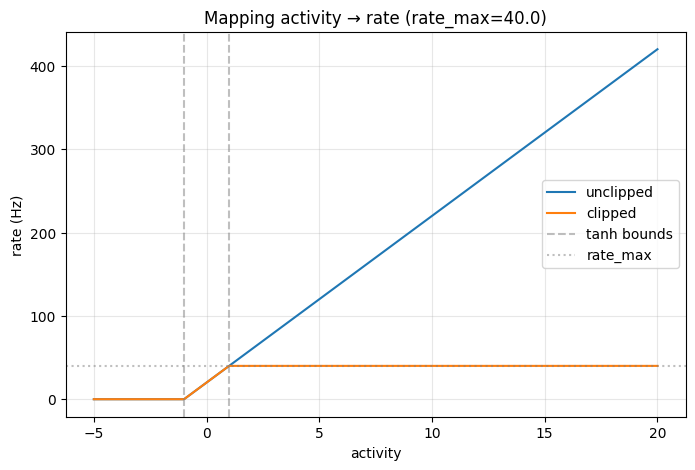

In [6]:
# Single-neuron example: activity → rate mapping curve
activity_grid = np.linspace(-5, 20, 400)
rates_unclip = activity_to_rates(activity_grid, clip_rates=False)
rates_clip = activity_to_rates(activity_grid, clip_rates=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(activity_grid, rates_unclip, label="unclipped")
ax.plot(activity_grid, rates_clip, label="clipped")
ax.axvline(-1, color="gray", linestyle="--", alpha=0.5, label="tanh bounds")
ax.axvline(1, color="gray", linestyle="--", alpha=0.5)
ax.axhline(RATE_MAX, color="gray", linestyle=":", alpha=0.5, label="rate_max")
ax.set_xlabel("activity")
ax.set_ylabel("rate (Hz)")
ax.set_title(f"Mapping activity → rate (rate_max={RATE_MAX})")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()